In [20]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
from emp_pdv import *
from pdv_plots import *
from pdv_analysis import *

In [3]:
set_style()

In [14]:
max_delta = 1000

# date params
load_from = pd.to_datetime("1995-01-01")
train_start_date = pd.to_datetime("2012-06-01")
test_start_date = pd.to_datetime("2019-01-01")
test_end_date = pd.to_datetime("2026-03-20")

# index and vol params
index = "USO"
vol = "^OVX"

# EODHD Suffix
index_suffix = None # "US"
vol_suffix = None # "INDX"

source = "yf" # "eodhd", "csv"
api_key = None

# model params
KernelClass = TSPL
model_spec = (1, 2) # (("neg", 1), 2)
spans = [10, 20, 120, 250]
cv_splits = 0 # 5
use_lasso = False
plot = False
neg_ret_feat = False
pos_ret_feat = False
forecast = 0

power=1: coefs=[-0.97225013 -1.50894401 -2.07443687 -1.76863786], sum=-6.324269
spans chosen: [ 10  20 120 250]
power=2: coefs=[0.49672423 0.46571034 0.30170098 0.21740433], sum=1.481540
spans chosen: [ 10  20 120 250]


c:\Users\Jacob\Projects\Python\diss\emp_pdv.py:183: RuntimeWarning: invalid value encountered in power
  return (tau + delta) ** (-alpha)


beta_0/intercept: 0.04802143274350511, betas: [-0.06186823  0.92049497], alphas: [4.493953   1.96074586], deltas: [0.51805045 0.09401901]
train RMSE: 0.03254106295526408, train R-squared: 0.9199577145768482, test RMSE: 0.1190405763269864, test R-squared: 0.6890226148325523


Text(2022-05-20 00:00:00, 190.0, 'Original test end ')

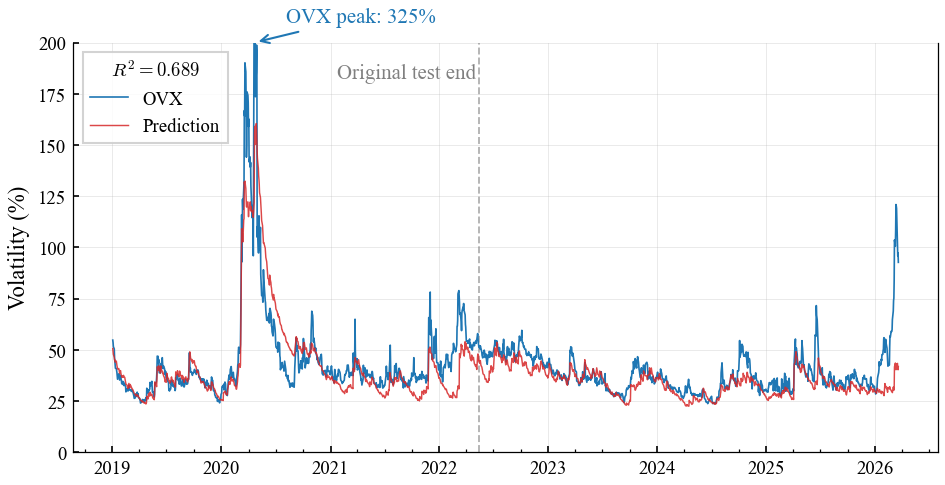

In [18]:
ovx12 = empirical_study(
    load_from, train_start_date, test_start_date, test_end_date,
    index, vol, index_suffix, vol_suffix,
    max_delta, KernelClass, model_spec,
    spans, cv_splits, use_lasso, plot,
    neg_ret_feat=False, pos_ret_feat=False,
    forecast=forecast, api_key=api_key, source=source
)

vol_ts_plot_test = plot_vol_timeseries(ovx12["test_pred"]*100, ovx12["test_true"]*100, label_true="OVX", label_pred="Prediction", r2=ovx12["test_r2"])
vol_ts_plot_test = clip_yaxis(vol_ts_plot_test, 200)
vol_ts_plot_test.axes[0].axvline(pd.Timestamp('2022-05-15'), linestyle='--', color='grey', alpha=0.6)
vol_ts_plot_test.axes[0].text(pd.Timestamp('2022-05-20'), 200 * 0.95, 'Original test end ',
        fontsize=10, color='grey', ha="right", va='top')

power=1: coefs=[-0.01116477 -0.00559325 -0.00427205 -0.0038413 ], sum=-0.024871
spans chosen: [ 10  20 120 250]
power=2: coefs=[0.01833572 0.01649244 0.01145434 0.00885649], sum=0.055139
spans chosen: [ 10  20 120 250]


c:\Users\Jacob\Projects\Python\diss\emp_pdv.py:183: RuntimeWarning: invalid value encountered in power
  return (tau + delta) ** (-alpha)
c:\Users\Jacob\Projects\Python\diss\emp_pdv.py:183: RuntimeWarning: invalid value encountered in power
  return (tau + delta) ** (-alpha)


beta_0/intercept: 0.023629060969432434, betas: [-0.00119041  0.92949976], alphas: [9.99995216 1.44706893], deltas: [0.04203438 0.04480895]
train RMSE: 0.017615702244129446, train R-squared: 0.8062187792173068, test RMSE: 0.02829440379180645, test R-squared: 0.6910046125570124


Text(2022-05-20 00:00:00, 47.5, 'Original test end ')

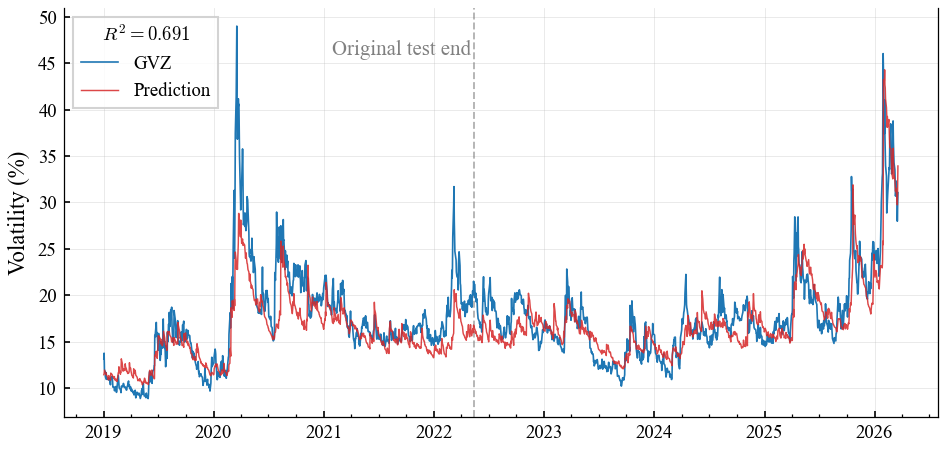

In [19]:
gvz12 = empirical_study(
    load_from, train_start_date, test_start_date, test_end_date,
    "GLD", "^GVZ", None, None,
    max_delta, KernelClass, model_spec,
    spans, cv_splits, use_lasso, plot,
    neg_ret_feat=False, pos_ret_feat=False,
    forecast=forecast, api_key=api_key, source=source
)

vol_ts_plot_test = plot_vol_timeseries(gvz12["test_pred"]*100, gvz12["test_true"]*100, label_true="GVZ", label_pred="Prediction", r2=gvz12["test_r2"])
vol_ts_plot_test.axes[0].axvline(pd.Timestamp('2022-05-15'), linestyle='--', color='grey', alpha=0.6)
vol_ts_plot_test.axes[0].text(pd.Timestamp('2022-05-20'), 50 * 0.95, 'Original test end ',
        fontsize=10, color='grey', ha="right", va='top')